In [8]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [9]:
students     = ["A", "B", "C", "D", "E"]
study_hours  = [2,   4,   6,   8,   10]  
exam_scores  = [70,  75,  85,  90,  95] 


df = pd.DataFrame({
    "student":    students,
    "x":          study_hours,
    "y":          exam_scores,
})

In [10]:
df["x2"] = df["x"] ** 2          # square of each x value
df["y2"] = df["y"] ** 2          # square of each y value
df["xy"] = df["x"] * df["y"]     # product of x and y for each row
df

,student,x,y,x2,y2,xy
0,A,2,70,4,4900,140
1,B,4,75,16,5625,300
2,C,6,85,36,7225,510
3,D,8,90,64,8100,720
4,E,10,95,100,9025,950


In [11]:
n = len(df)
sum_x  = df["x"].sum()
sum_y  = df["y"].sum()
sum_x2 = df["x2"].sum()
sum_y2 = df["y2"].sum()
sum_xy = df["xy"].sum()


print(f"n: {n}")
print(f"sum_x: {sum_x}")
print(f"sum_y: {sum_y}")
print(f"sum_x2: {sum_x2}")
print(f"sum_y2: {sum_y2}")
print(f"sum_xy: {sum_xy}")

n: 5
sum_x: 30
sum_y: 415
sum_x2: 220
sum_y2: 34875
sum_xy: 2620


In [12]:
numerator   = n * sum_xy - sum_x * sum_y
denominator = math.sqrt((n * sum_x2 - sum_x ** 2) *(n * sum_y2 - sum_y ** 2))
r = numerator / denominator
r

np.float64(0.9912407071619304)

In [13]:

if   abs(r) >= 0.9: 
    strength = "very strong"
elif abs(r) >= 0.7:
    strength = "strong"
elif abs(r) >= 0.4: 
    strength = "moderate"
else:               
    strength = "weak"
    
print(f"The Pearson correlation coefficient (r) is: {r:.2f}")
print(f"This indicates a {strength} positive correlation between study hours and exam scores.")


The Pearson correlation coefficient (r) is: 0.99
This indicates a very strong positive correlation between study hours and exam scores.


In [14]:
print("=" * 52)
print("  TASK 2 – PEARSON CORRELATION COEFFICIENT")
print("=" * 52)
print()
print(df[["student","x","y","x2","y2","xy"]].to_string(index=False))
print()
print(f"  n       = {n}")
print(f"  Σx      = {sum_x}")
print(f"  Σy      = {sum_y}")
print(f"  Σx²     = {sum_x2}")
print(f"  Σy²     = {sum_y2}")
print(f"  Σxy     = {sum_xy}")
print()
print(f"  Numerator   = {n}×{sum_xy} − {sum_x}×{sum_y} = {numerator}")
print(f"  Denominator = {denominator:.4f}")
print(f"  r           = {r:.4f}  ({strength} correlation)")
print("=" * 52)

  TASK 2 – PEARSON CORRELATION COEFFICIENT

student  x  y  x2   y2  xy
      A  2 70   4 4900 140
      B  4 75  16 5625 300
      C  6 85  36 7225 510
      D  8 90  64 8100 720
      E 10 95 100 9025 950

  n       = 5
  Σx      = 30
  Σy      = 415
  Σx²     = 220
  Σy²     = 34875
  Σxy     = 2620

  Numerator   = 5×2620 − 30×415 = 650
  Denominator = 655.7439
  r           = 0.9912  (very strong correlation)


C:\Users\Admin\AppData\Local\Temp\ipykernel_10156\2414118563.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


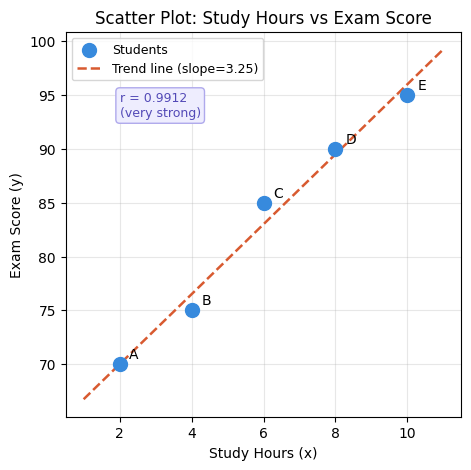

<Figure size 1000x500 with 0 Axes>

In [15]:
fig = plt.figure(figsize=(12, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.scatter(
    df["x"], df["y"],
    color="#378ADD",   
    s=100,            
    zorder=5,          
    label="Students"
)

for _, row in df.iterrows():
    ax1.annotate(
        row["student"],
        (row["x"], row["y"]),
        textcoords="offset points",
        xytext=(7, 4),        # shift 7px right, 4px up so text doesn't overlap dot
        fontsize=10
    )

slope_trend, intercept_trend = np.polyfit(df["x"], df["y"], 1)  # degree-1 = straight line
x_line = np.linspace(df["x"].min() - 1, df["x"].max() + 1, 200) # 200 smooth points
y_line = slope_trend * x_line + intercept_trend

ax1.plot(
    x_line, y_line,
    color="#D85A30",   # orange dashed line
    lw=1.8,
    ls="--",
    label=f"Trend line (slope={slope_trend:.2f})"
)

# Annotate the r value directly on the chart
ax1.text(
    2, 93,
    f"r = {r:.4f}\n({strength})",
    fontsize=9,
    color="#534AB7",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#EEEDFE", edgecolor="#AFA9EC")
)

ax1.set_xlabel("Study Hours (x)")
ax1.set_ylabel("Exam Score (y)")
ax1.set_title("Scatter Plot: Study Hours vs Exam Score")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.figure(figsize=(10, 5))
plt.show()